In [118]:
import pandas as pd

reading the cleaned csv file

In [119]:
df = pd.read_csv(
    "../1_datasets/data/clean_datasets/fivc_gaza_october_cleaned.csv",
    parse_dates=["Date"],
)
df

,event_id,Date,Country,administrative_division_1,administrative_division_2,Location,Reported Perpetrator Name,Method of Attack,Object Affected,Sub-Object Affected,Latitude,Longitude,Geo-Precision
0,"3,236",2023-10-07,occupied Palestinian territories,Gaza Strip,Gaza City,Sheikh Radwan,Armed Forces of Israel,Air or Drone Strike,Crops and Lands,Agricultural Land,31.53,34.47,[2] 25km precision
1,"3,235",2023-10-07,occupied Palestinian territories,Gaza Strip,Khan Younis,Qizan Al-Najjar,Armed Forces of Israel,Air or Drone Strike,Crops and Lands,Agricultural Land,31.33,34.29,[2] 25km precision
2,"3,234",2023-10-07,occupied Palestinian territories,Gaza Strip,unknown,unknown,Armed Forces of Israel,Air or Drone Strike,Crops and Lands,Agricultural Land,31.52,34.51,[2] 25km precision
3,"3,233",2023-10-07,occupied Palestinian territories,Gaza Strip,North Gaza,Beit Lahia,Armed Forces of Israel,Air or Drone Strike,Crops and Lands,Agricultural Land,31.55,34.51,[2] 25km precision
4,"3,232",2023-10-07,occupied Palestinian territories,Gaza Strip,Deir el-Balah,Nuseirat Refugee Camp,Armed Forces of Israel,"Artillery, Shelling or Missile Fire",Crops and Lands,Agricultural Land,31.45,34.40,[2] 25km precision
...,...,...,...,...,...,...,...,...,...,...,...,...,...
279,"3,335",2024-09-03,occupied Palestinian territories,Gaza Strip,Khan Younis,unknown,Armed Forces of Israel,Air or Drone Strike,Crops and Lands,Agricultural Land,31.32,34.34,[2] 25km precision
280,"3,334",2024-09-05,occupied Palestinian territories,Gaza Strip,North Gaza,unknown,Armed Forces of Israel,Air or Drone Strike,Crops and Lands,Agricultural Land,31.56,34.48,[2] 25km precision
281,"3,333",2024-09-11,occupied Palestinian territories,Gaza Strip,Gaza City,unknown,Armed Forces of Israel,Air or Drone Strike,Food Supply Chains,Bakery,31.53,34.46,[2] 25km precision
282,"3,331",2024-09-13,occupied Palestinian territories,Gaza Strip,Gaza City,unknown,Armed Forces of Israel,Air or Drone Strike,Food Supply Chains,Bakery,31.50,34.47,[2] 25km precision


inspecting the number of rows and the number of columns, there is 13 columns and 284 rows

In [120]:
df.shape

(284, 13)

getting information about the variables in the dataset

In [121]:
df.info()
print(df["Date"].dtype)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284 entries, 0 to 283
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   event_id                   284 non-null    object        
 1   Date                       284 non-null    datetime64[ns]
 2   Country                    284 non-null    object        
 3   administrative_division_1  284 non-null    object        
 4   administrative_division_2  284 non-null    object        
 5   Location                   284 non-null    object        
 6   Reported Perpetrator Name  284 non-null    object        
 7   Method of Attack           284 non-null    object        
 8   Object Affected            284 non-null    object        
 9   Sub-Object Affected        284 non-null    object        
 10  Latitude                   284 non-null    float64       
 11  Longitude                  284 non-null    float64       
 12  Geo-Prec

creating a function that creates bar graphs to show the distribution of each variable

In [122]:
def show_dist(col_data):
    """a function that creates a histogram to explore columns (variables) in the dataset
    input: column in the dataset
    output: histogram showing the distribution of values in the column and highlight the mode"""

    from matplotlib import pyplot as plt

    # get stats
    # min_val=col_data.min()
    # max_val=col_data.max()
    # mean_val=col_data.mean()
    # mid_val=col_data.median()
    mod_val = col_data.mode()[0]
    print(mod_val)
    fig = plt.figure(figsize=(14, 6))
    counts = col_data.value_counts().sort_index()
    ax = fig.gca()
    counts.plot.bar(ax=ax, color="steelblue")
    plt.xticks(rotation=90)
    # fig.hist(col_data)
    plt.ylabel("frequency")
    # Add lines for the mean, median, and mode
    # ax[0].axvline(x=min_val, color = 'gray', linestyle='dashed', linewidth = 2)
    # ax[0].axvline(x=mean_val, color = 'cyan', linestyle='dashed', linewidth = 2)
    # fig.axvline(x=mid_val, color = 'red', linestyle='dashed', linewidth = 2)
    plt.axvline(x=mod_val, color="yellow", linestyle="dashed", linewidth=2)
    # ax[0].axvline(x=max_val, color = 'gray', linestyle='dashed', linewidth = 2)
    plt.title(col_data.name)


# show_dist(df['Location'])

This dataset explores food insecurity related to war events in the Gaza Strip

exploring the administrative_division_2 column
**What are the most affected cities?**


Deir el-Balah


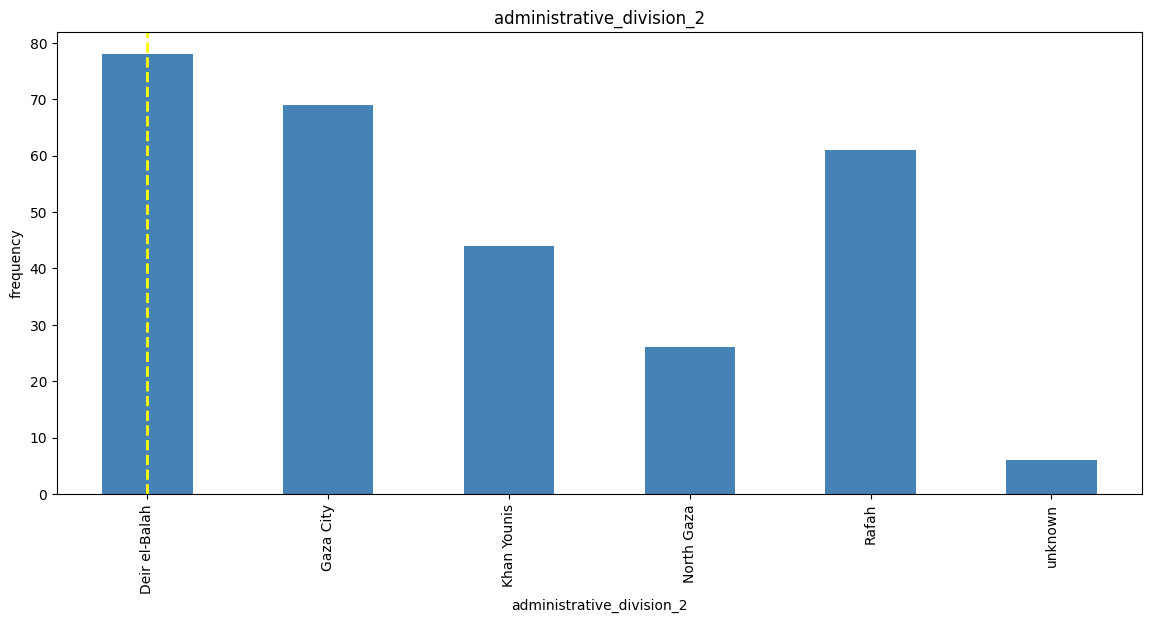

In [123]:
show_dist(df["administrative_division_2"])

In [124]:
df["administrative_division_2"].value_counts()

administrative_division_2
Deir el-Balah    78
Gaza City        69
Rafah            61
Khan Younis      44
North Gaza       26
unknown           6
Name: count, dtype: int64

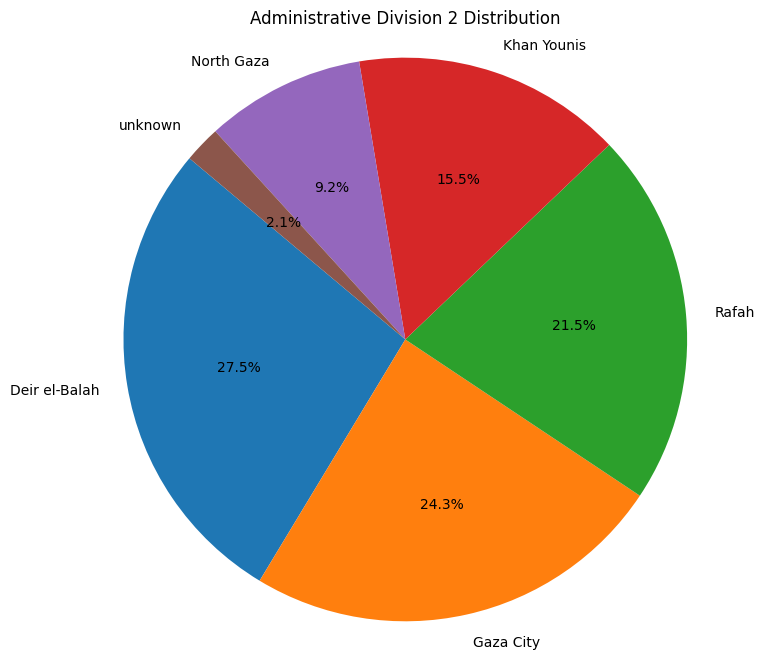

In [125]:
import matplotlib.pyplot as plt

# Data
labels = ["Deir el-Balah", "Gaza City", "Rafah", "Khan Younis", "North Gaza", "unknown"]
counts = [78, 69, 61, 44, 26, 6]

# Create pie chart
plt.figure(figsize=(8, 8))
plt.pie(counts, labels=labels, autopct="%1.1f%%", startangle=140)
plt.title("Administrative Division 2 Distribution")
plt.axis("equal")  # Makes it a circle
plt.show()

Deir el-Balah is the most affected region, and from the plot we can see that Gaza city has been affected more than 65 times coming directly after Deir el-Balah.
24.3% of the war events are in Gaza city and it is a very high populated city (before the war) and it has many of Gaza's universities.


Armed Forces of Israel


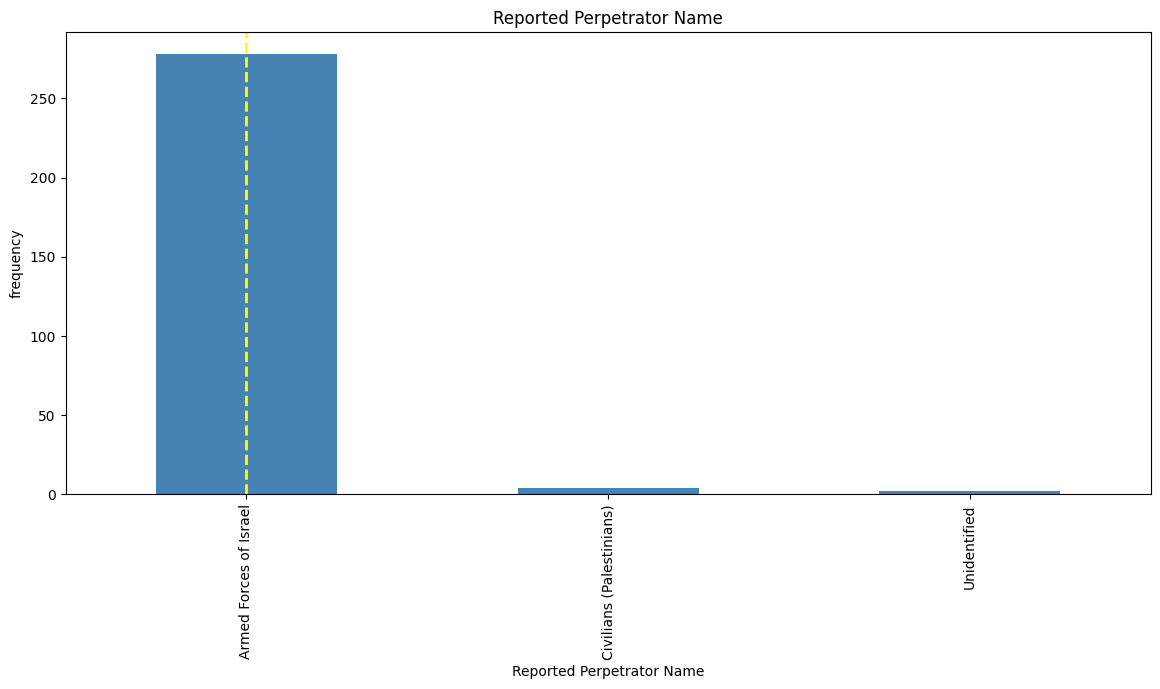

In [126]:
# exploring the Reported Perpetrator Name column
show_dist(df["Reported Perpetrator Name"])

In [127]:
df.groupby("administrative_division_2")["Reported Perpetrator Name"].value_counts()

administrative_division_2  Reported Perpetrator Name
Deir el-Balah              Armed Forces of Israel       76
                           Civilians (Palestinians)      2
Gaza City                  Armed Forces of Israel       67
                           Unidentified                  2
Khan Younis                Armed Forces of Israel       44
North Gaza                 Armed Forces of Israel       26
Rafah                      Armed Forces of Israel       59
                           Civilians (Palestinians)      2
unknown                    Armed Forces of Israel        6
Name: count, dtype: int64

exploring the method of attack column

Air or Drone Strike


Method of Attack
Air or Drone Strike                    176
Artillery, Shelling or Missile Fire     51
Firearms                                34
Unidentified                            15
Looting or Robbery                       4
Explosive                                2
Arson                                    1
Demolition                               1
Name: count, dtype: int64

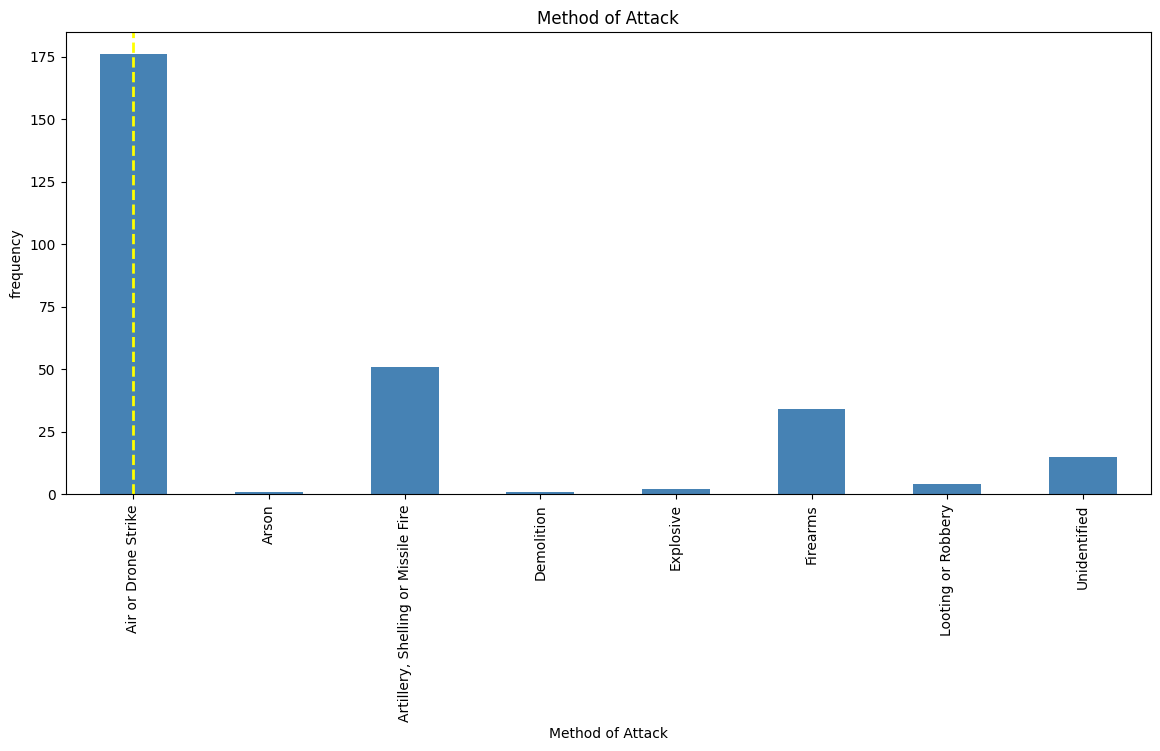

In [128]:
show_dist(df["Method of Attack"])
df["Method of Attack"].value_counts()

the most frequent attacking methods are 'Air or Drone Strike', 'Artillery, Shelling or Missile Fire',and Firearms.
we have 15 undefined attacking methods.

**what is the most affected object?**
explore the object affected  column

### Some cleaning first

In [129]:
df[df["Sub-Object Affected"] == "Agricultural Land"]["Object Affected"].value_counts()

Object Affected
Crops and Lands    150
Population           1
Name: count, dtype: int64

as we can see there is one "Agricultural Land"in the population category, which does not make sense, let us fix it and put in the 'Crops and Lands' object category.

In [130]:
df.loc[
    (df["Sub-Object Affected"] == "Agricultural Land")
    & (df["Object Affected"] == "Population"),
    "Object Affected",
] = "Crops and Lands"

let us check now

In [131]:
df[df["Sub-Object Affected"] == "Agricultural Land"]["Object Affected"].value_counts()

Object Affected
Crops and Lands    151
Name: count, dtype: int64

making sure no duplicates after the change

In [132]:
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 0


In [133]:
print(df[df.duplicated(keep=False)])

Empty DataFrame
Columns: [event_id, Date, Country , administrative_division_1, administrative_division_2, Location, Reported Perpetrator Name, Method of Attack, Object Affected, Sub-Object Affected, Latitude, Longitude, Geo-Precision]
Index: []


all done now, back to the EDA

Crops and Lands


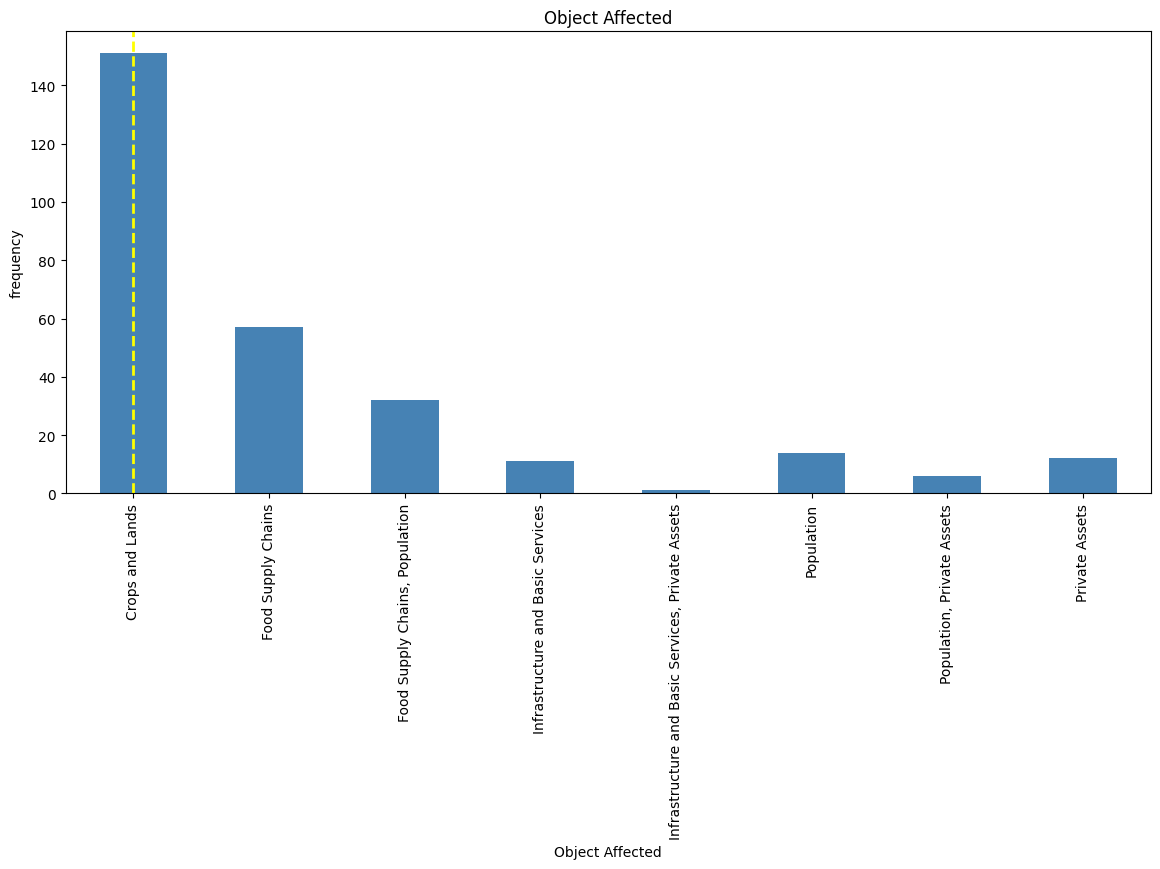

In [134]:
show_dist(df["Object Affected"])

the most affected objects are 'crops and lands', then, 'food supply chains', and lastly comes 'food supply chains,populations'.

In [135]:
df.groupby("Object Affected")["Sub-Object Affected"].value_counts()

Object Affected                                    Sub-Object Affected                  
Crops and Lands                                    Agricultural Land                        151
Food Supply Chains                                 Bakery                                    24
                                                   Market                                    24
                                                   Food Aid                                   4
                                                   Flour Mill                                 1
                                                   Food                                       1
                                                   Food Aid Truck                             1
                                                   Food Aid Warehouse                         1
                                                   Food Warehouse                             1
Food Supply Chains, Population                 

In [136]:
# checking method of attack for 'Agricultural Land'
df[df["Sub-Object Affected"] == "Agricultural Land"]["Method of Attack"].value_counts()

Method of Attack
Air or Drone Strike                    115
Artillery, Shelling or Missile Fire     33
Unidentified                             3
Name: count, dtype: int64

In [137]:
# checking method of attack for 'Market'
df[df["Sub-Object Affected"] == "Market"]["Method of Attack"].value_counts()

Method of Attack
Air or Drone Strike                    21
Artillery, Shelling or Missile Fire     3
Name: count, dtype: int64

In [138]:
# checking method of attack for "Bakery"
df[df["Sub-Object Affected"] == "Bakery"]["Method of Attack"].value_counts()

Method of Attack
Air or Drone Strike    22
Unidentified            2
Name: count, dtype: int64

In [139]:
# checking method of attack for "People Waiting for or Receiving Aid"
df[df["Sub-Object Affected"] == "People Waiting for or Receiving Aid"][
    "Method of Attack"
].value_counts()

Method of Attack
Firearms                               21
Artillery, Shelling or Missile Fire     4
Explosive                               2
Air or Drone Strike                     2
Name: count, dtype: int64

during the period (October 2023 to mid-September 2024) there were around 151 war events that affected 'Agricultural Lands'(crops and lands), as well as 24 events that affected markets and 24 events that affected bakeries (food supply chains) - which reflects the food insecurity.
there were also 29 war events that affected People Waiting for or Receiving Aid (Food Supply Chains, Population )

In [140]:
df.groupby("Sub-Object Affected")["Reported Perpetrator Name"].value_counts()
# df.groupby('Sub-Object Affected')['administrative_division_2'].value_counts()

Sub-Object Affected                    Reported Perpetrator Name
Agricultural Land                      Armed Forces of Israel       151
Bakery                                 Armed Forces of Israel        24
Farm                                   Armed Forces of Israel         3
Farmer/s                               Armed Forces of Israel         8
Fishers                                Armed Forces of Israel         6
Fishers, Fishing Boats                 Armed Forces of Israel         5
Fishing Boats                          Armed Forces of Israel         7
Fishing Boats, Fishers                 Armed Forces of Israel         1
Fishing Port                           Armed Forces of Israel         5
Fishing Port, Fishing Boats            Armed Forces of Israel         1
Flour Mill                             Armed Forces of Israel         1
Food                                   Civilians (Palestinians)       1
Food Aid                               Civilians (Palestinians)       3

**from the period of July 2024 to september 2024, what is the most affected city?**
first step we are going to create a sub data frame that only contains data from July 2024 up to September 2024

In [141]:
sem_data = df[df["Date"].between("2024-07-01", "2024-09-30")]
first_mention = sem_data["Date"].min()
print(first_mention)

2024-07-09 00:00:00


we have dates from 2024-07-09 up to 2024-09-16

Deir el-Balah


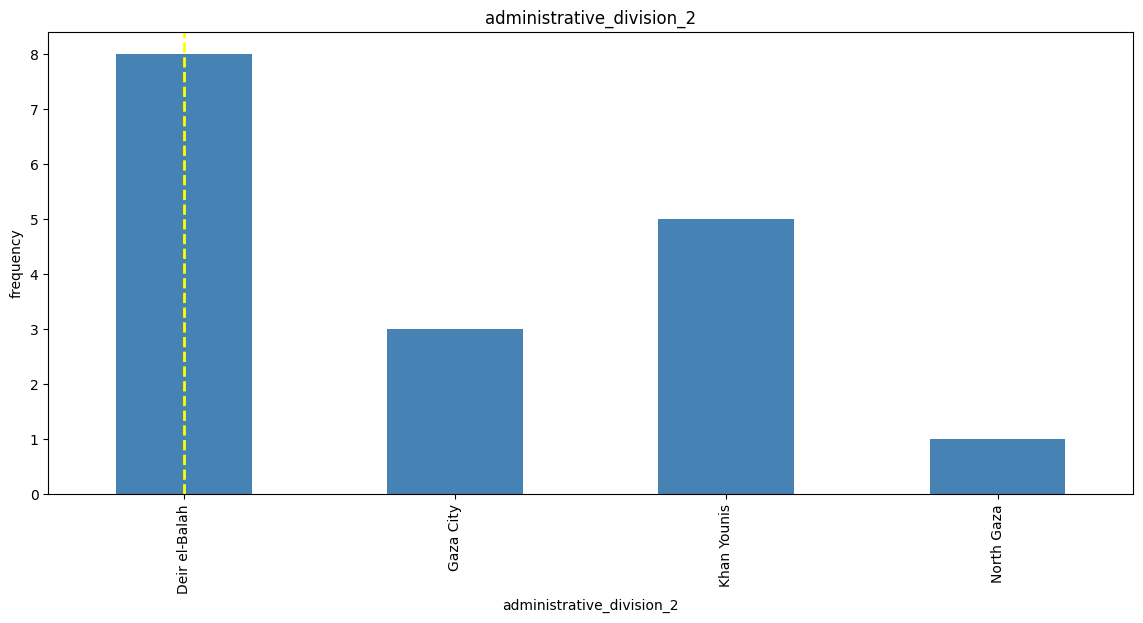

In [142]:
show_dist(sem_data["administrative_division_2"])

we can see even within this period of time most of the food insecurity related war events happened in Deir el-Balah with:

Deir el-Balah: 8 events

Khan Younis: 5 events


Air or Drone Strike


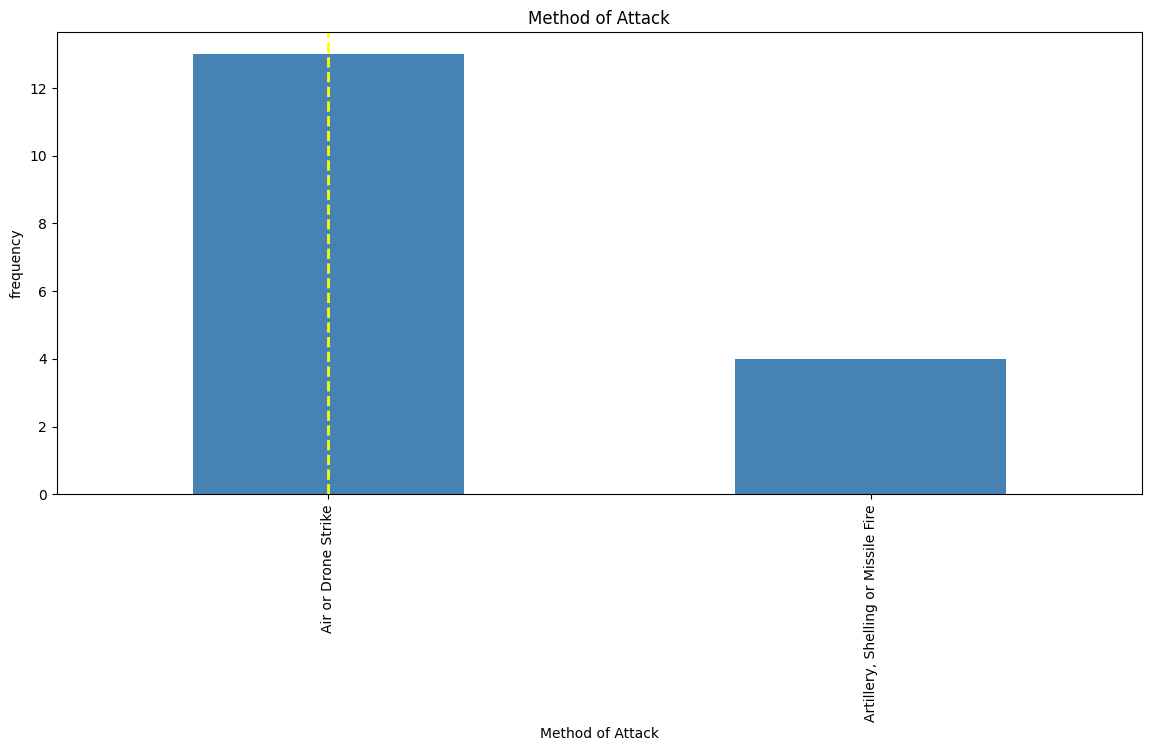

In [143]:
show_dist(sem_data["Method of Attack"])

let us check the most frequent Object Affected and Sub-Object Affected

Food Supply Chains


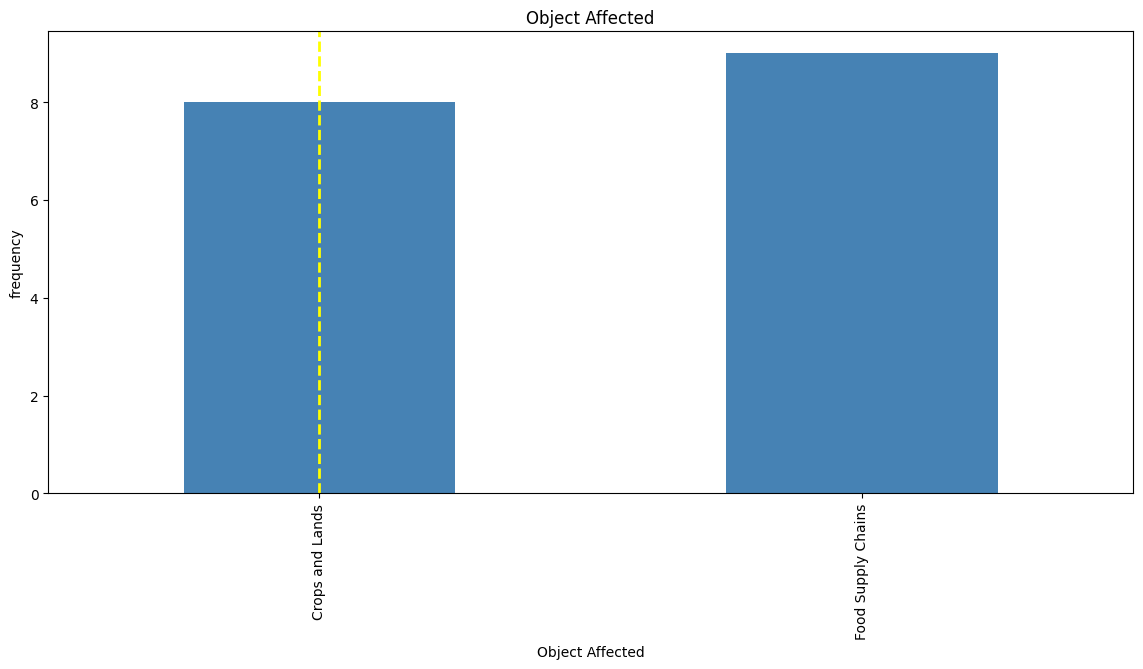

In [144]:
show_dist(sem_data["Object Affected"])

only two main objects got affected, Food Supply Chains(9 events) and Crops and Lands (8 events)
now let us check the most Sub-Object Affected

Agricultural Land


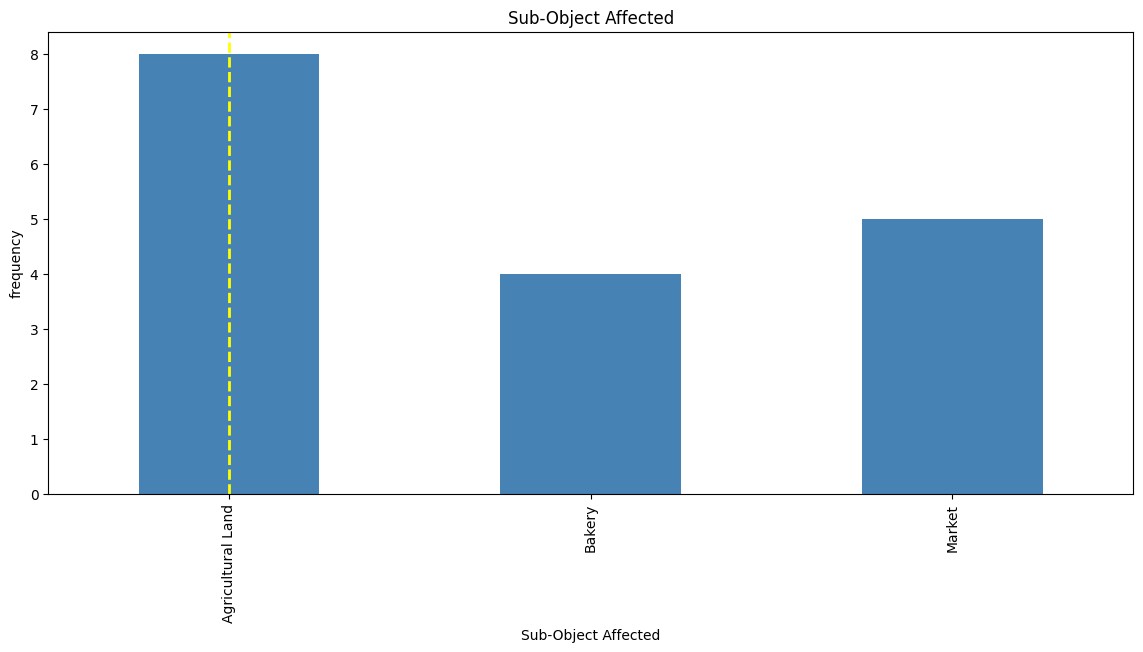

In [145]:
show_dist(sem_data["Sub-Object Affected"])

the most effected Sub-Object within the period of July to September 2024 is 

Agricultural Lands (8 events), then, markets (5 events), and lastly 4 war events affected bakeries.
